In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Display plots inside notebook
%matplotlib inline
from scipy import stats


In [10]:
from google.colab import files

uploaded = files.upload()


Saving DataCoSupplyChainDataset.csv to DataCoSupplyChainDataset.csv


In [12]:
df = pd.read_csv("DataCoSupplyChainDataset.csv",encoding="latin1")

In [14]:
# Missing value analysis

missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent.round(2)
})

# Show only columns having missing values
missing_summary = missing_summary[missing_summary["Missing Values"] > 0]

display(missing_summary)

,Missing Values,Percentage
Customer Lname,8,0.00
Customer Zipcode,3,0.00
Order Zipcode,155679,86.24
Product Description,180519,100.00


In [15]:
for column in missing_summary.index:
    print(column, ":", df[column].dtype)

Customer Lname : object
Customer Zipcode : float64
Order Zipcode : float64
Product Description : float64


In [13]:
numerical_columns = df.select_dtypes(include=np.number).columns

outlier_summary = []

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Column": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outliers": outliers,
        "Outlier %": round(outliers / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)

display(outlier_df.sort_values("Outliers", ascending=False))

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers,Outlier %
2,Benefit per order,7.000000,64.800003,57.800003,-79.700005,151.500008,18942,10.49
22,Order Profit Per Order,7.000000,64.800003,57.800003,-79.700005,151.500008,18942,10.49
18,Order Item Profit Ratio,0.080000,0.360000,0.280000,-0.340000,0.780000,17300,9.58
14,Order Item Discount,5.400000,29.990000,24.590000,-31.484999,66.874999,7537,4.18
17,Order Item Product Price,50.000000,199.990005,149.990005,-174.985008,424.975014,2048,1.13
27,Product Price,50.000000,199.990005,149.990005,-174.985008,424.975014,2048,1.13
3,Sales per customer,104.379997,247.399994,143.019997,-110.149998,461.929989,1943,1.08
21,Order Item Total,104.379997,247.399994,143.019997,-110.149998,461.929989,1943,1.08
10,Longitude,-98.446312,-66.370583,32.075729,-146.559906,-18.256989,1414,0.78
6,Customer Id,3258.500000,9779.000000,6520.500000,-6522.250000,19559.750000,1198,0.66


In [16]:
columns_to_treat = [
    "Sales",
    "Order Item Discount",
    "Order Item Discount Rate",
    "Order Profit Per Order",
    "Order Item Quantity",
    "Days for shipping (real)",
    "Days for shipment (scheduled)"
]
columns_to_treat = [
    col for col in columns_to_treat
    if col in df.columns
]

print("Columns selected for outlier treatment:")
print(columns_to_treat)

Columns selected for outlier treatment:
['Sales', 'Order Item Discount', 'Order Item Discount Rate', 'Order Profit Per Order', 'Order Item Quantity', 'Days for shipping (real)', 'Days for shipment (scheduled)']


In [19]:
zscore_results = []

for column in numerical_columns:

    data = df[column].dropna()

    z_scores = np.abs(stats.zscore(data))

    outliers = (z_scores > 3).sum()

    zscore_results.append({
        "Column": column,
        "Z-Score Outliers": outliers,
        "Outlier %": round(outliers / len(data) * 100, 2)
    })

zscore_df = pd.DataFrame(zscore_results)

display(zscore_df.sort_values("Z-Score Outliers", ascending=False))

,Column,Z-Score Outliers,Outlier %
18,Order Item Profit Ratio,6013,3.33
22,Order Profit Per Order,3608,2.00
2,Benefit per order,3608,2.00
14,Order Item Discount,2106,1.17
11,Order Customer Id,1577,0.87
6,Customer Id,1577,0.87
10,Longitude,1414,0.78
8,Department Id,854,0.47
17,Order Item Product Price,488,0.27
27,Product Price,488,0.27


In [20]:
mad_results = []

for column in numerical_columns:

    data = df[column].dropna()

    median = np.median(data)

    MAD = np.median(np.abs(data - median))

    # Avoid division by zero
    if MAD == 0:
        outliers = 0
    else:
        modified_z = 0.6745 * (data - median) / MAD
        outliers = (np.abs(modified_z) > 3.5).sum()

    mad_results.append({
        "Column": column,
        "MAD Outliers": outliers,
        "Outlier %": round(outliers / len(data) * 100, 2)
    })

mad_df = pd.DataFrame(mad_results)

display(mad_df.sort_values("MAD Outliers", ascending=False))

,Column,MAD Outliers,Outlier %
17,Order Item Product Price,34770,19.26
27,Product Price,34770,19.26
18,Order Item Profit Ratio,14897,8.25
22,Order Profit Per Order,13317,7.38
2,Benefit per order,13317,7.38
14,Order Item Discount,7538,4.18
10,Longitude,1414,0.78
8,Department Id,854,0.47
21,Order Item Total,588,0.33
3,Sales per customer,588,0.33


In [22]:
df_clean = df.copy()

In [23]:
for column in numerical_columns:

    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean[column] = df_clean[column].clip(
        lower=lower,
        upper=upper
    )

print("Outliers rectified using IQR capping.")

Outliers rectified using IQR capping.


Benefit per order: 18942 values changed
Sales per customer: 1943 values changed
Customer Id: 1198 values changed
Customer Zipcode: 3 values changed
Department Id: 362 values changed
Latitude: 9 values changed
Longitude: 1414 values changed
Order Customer Id: 1198 values changed
Order Item Discount: 7537 values changed
Order Item Product Price: 2048 values changed
Order Item Profit Ratio: 17300 values changed
Sales: 488 values changed
Order Item Total: 1943 values changed
Order Profit Per Order: 18942 values changed
Order Zipcode: 155679 values changed
Product Description: 180519 values changed
Product Price: 2048 values changed


In [24]:
print("Original shape :", df.shape)
print("Cleaned shape  :", df_clean.shape)

Original shape : (180519, 53)
Cleaned shape  : (180519, 53)


Number of numerical columns: 29


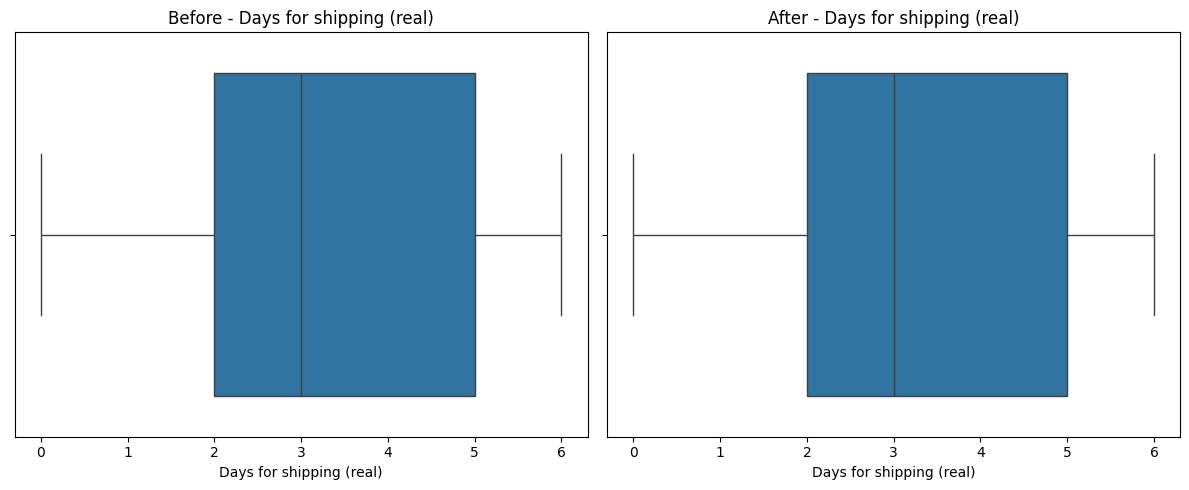

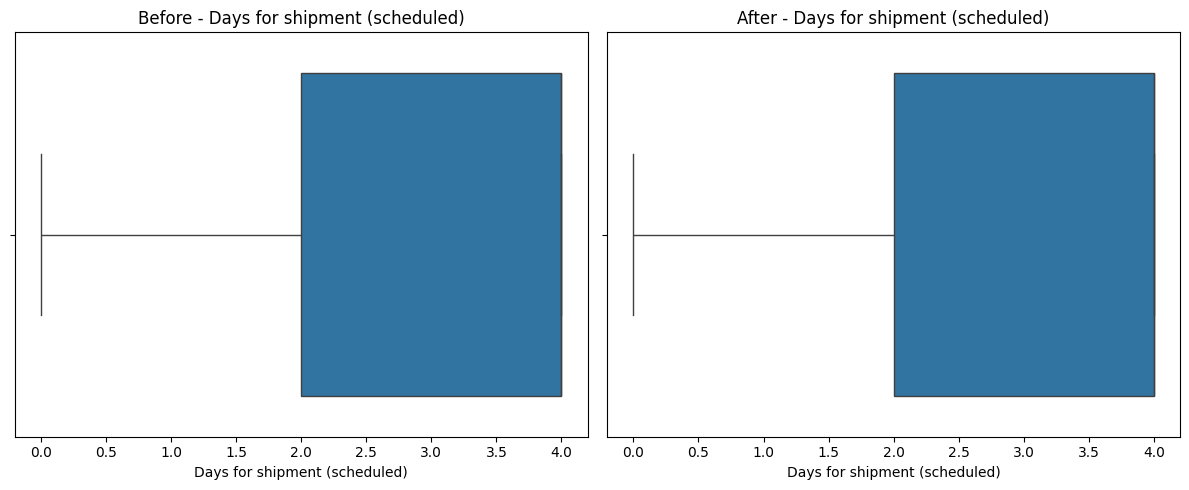

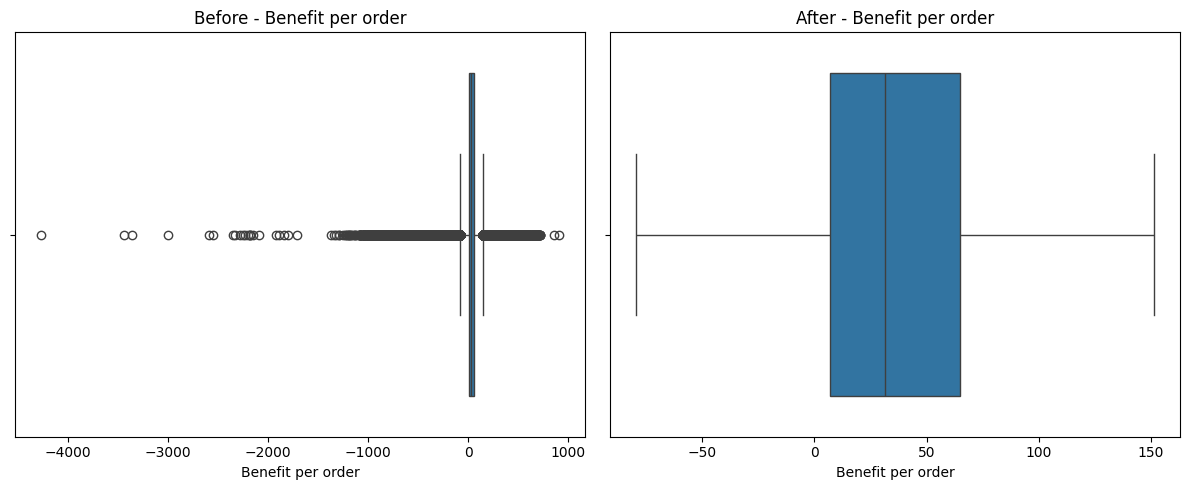

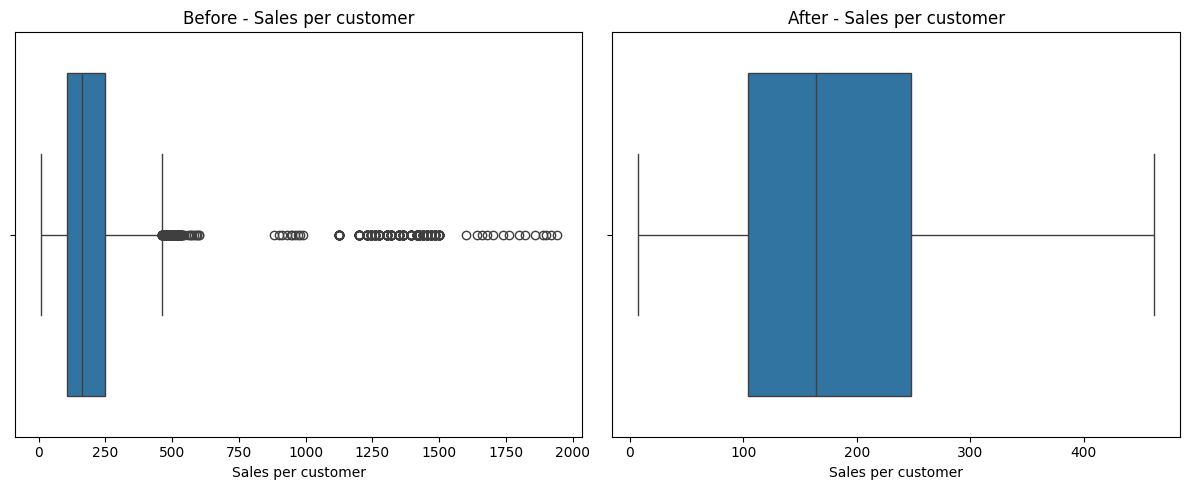

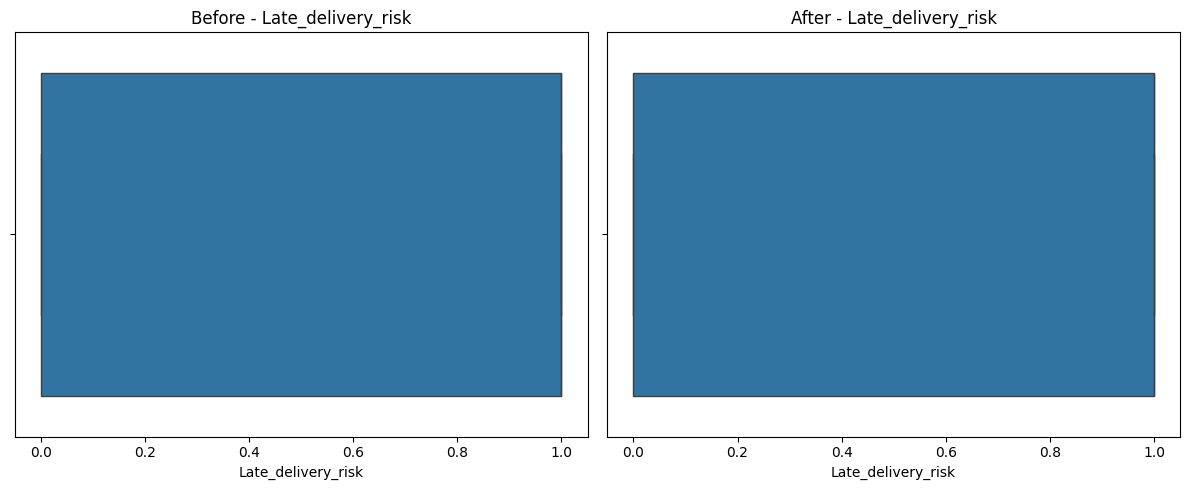

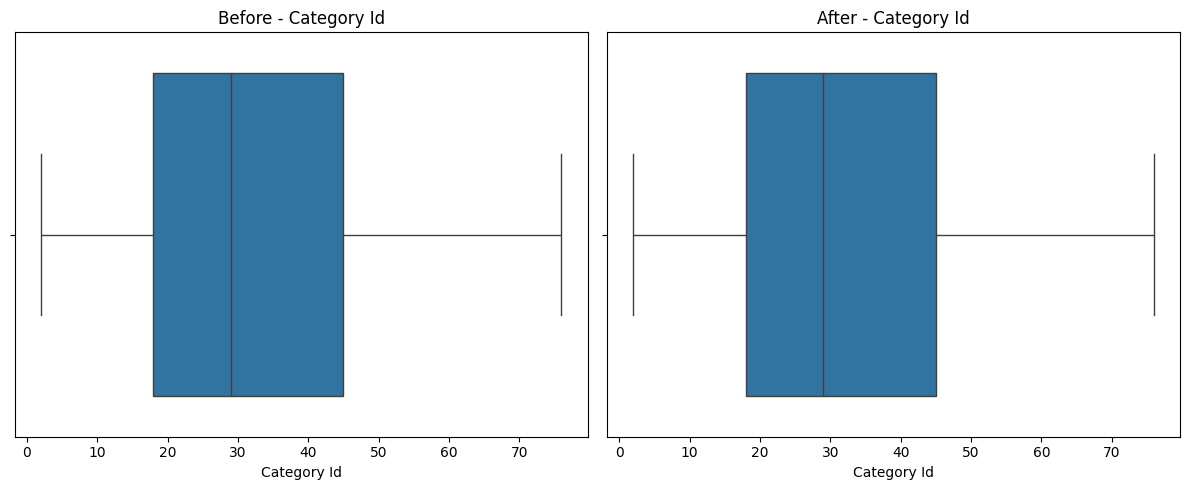

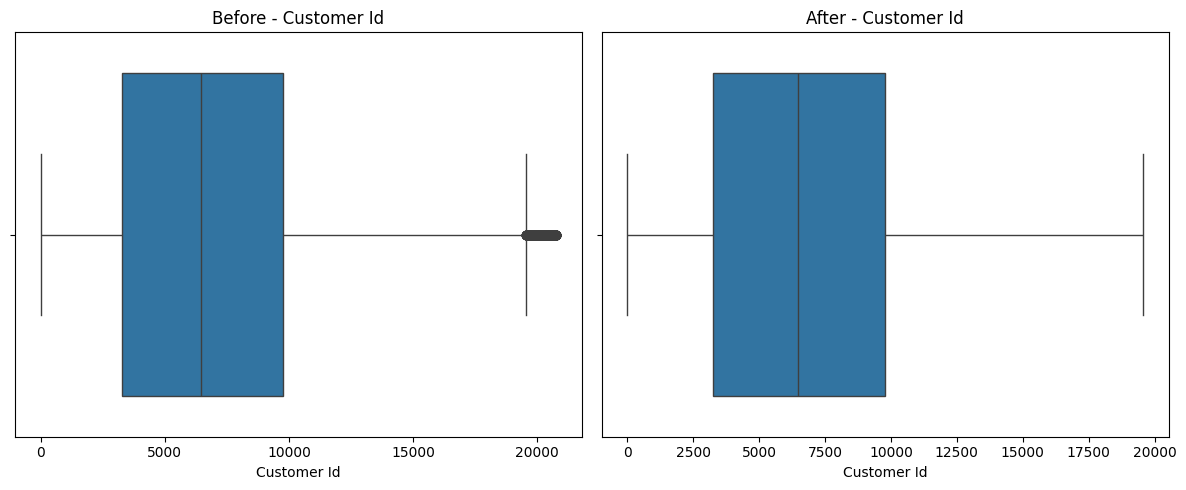

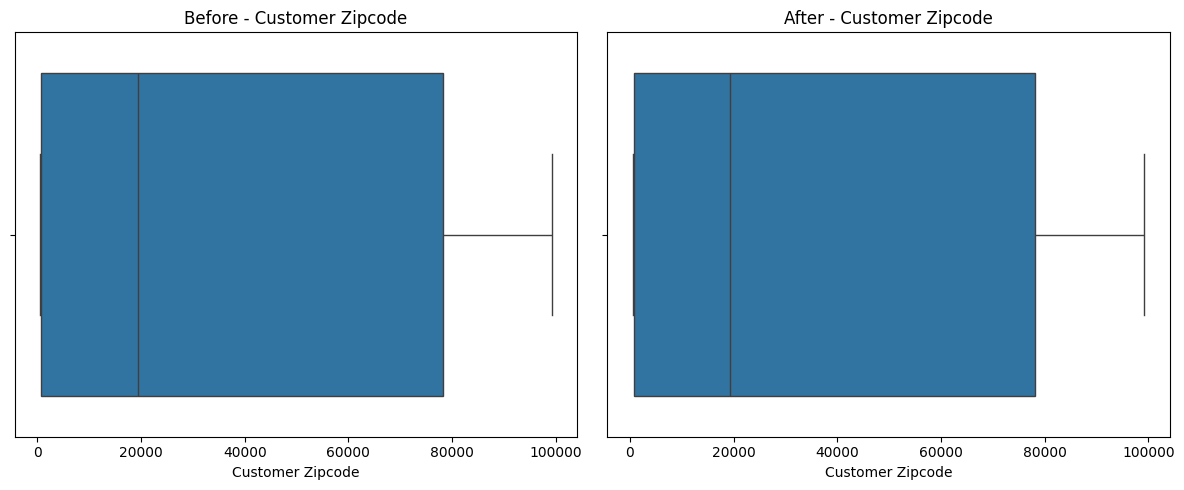

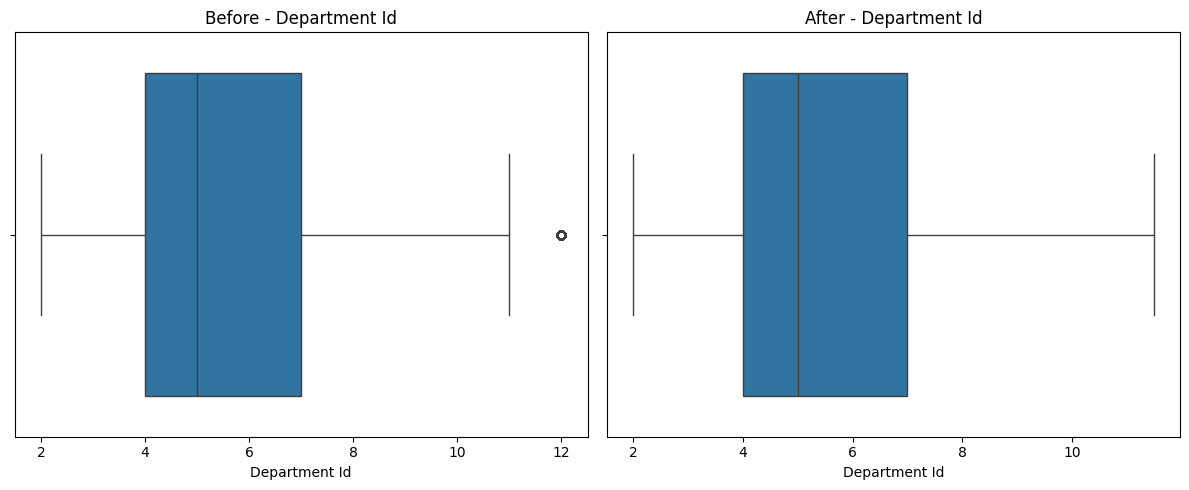

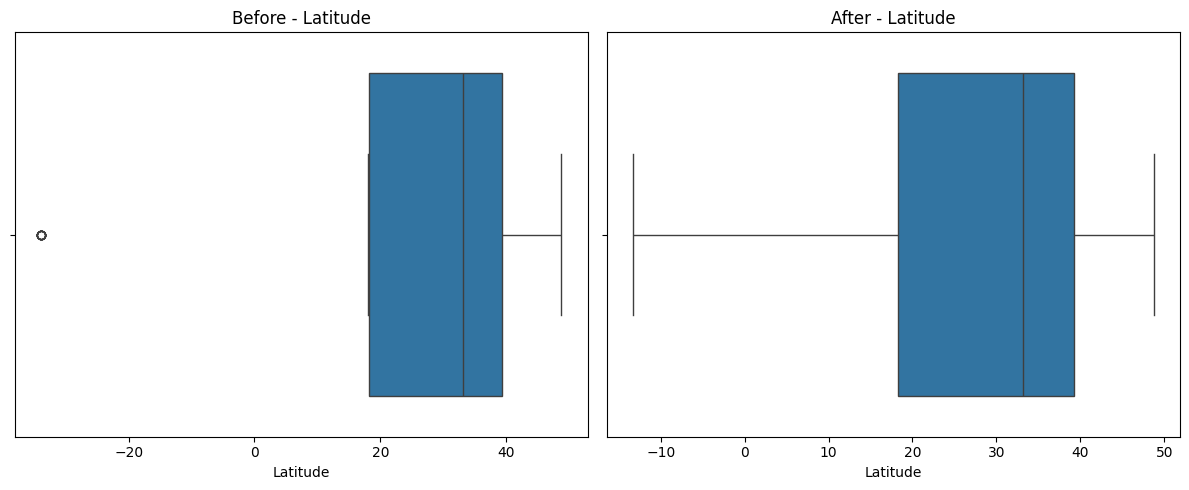

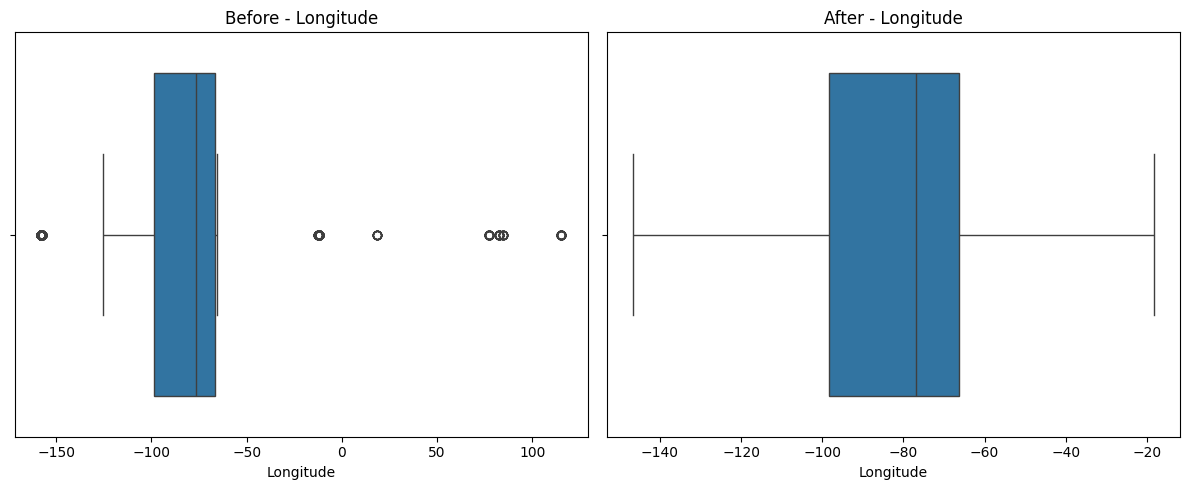

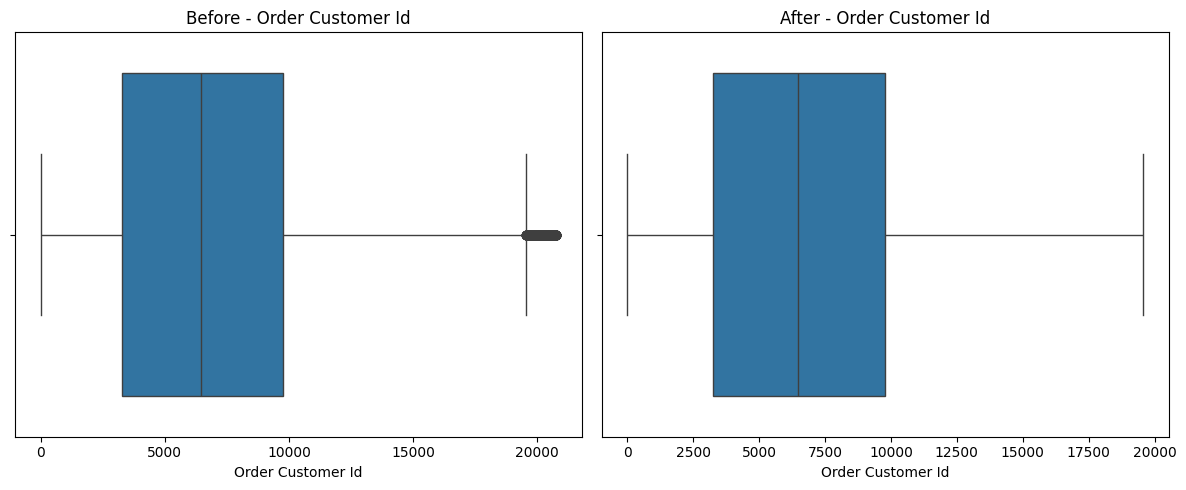

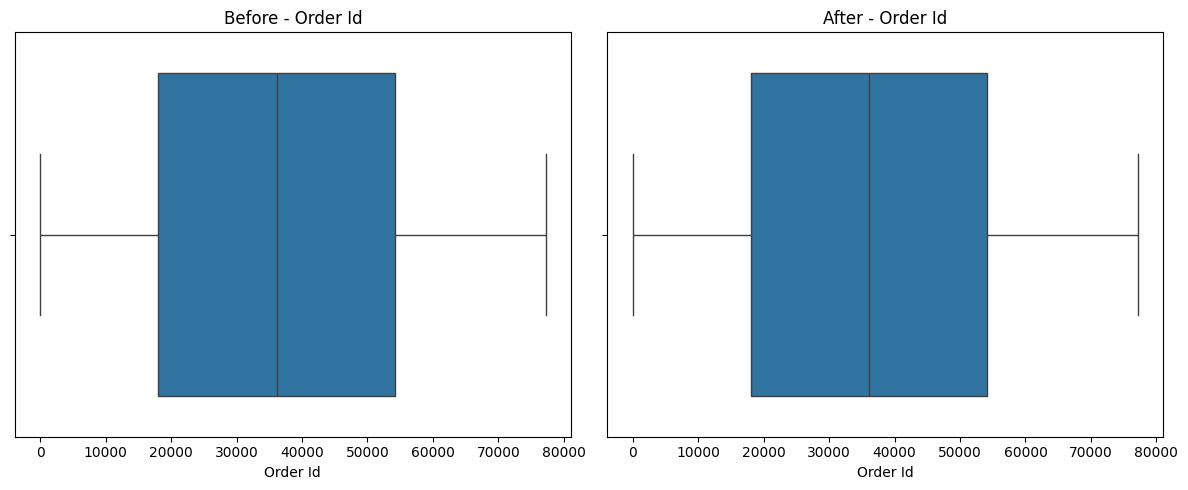

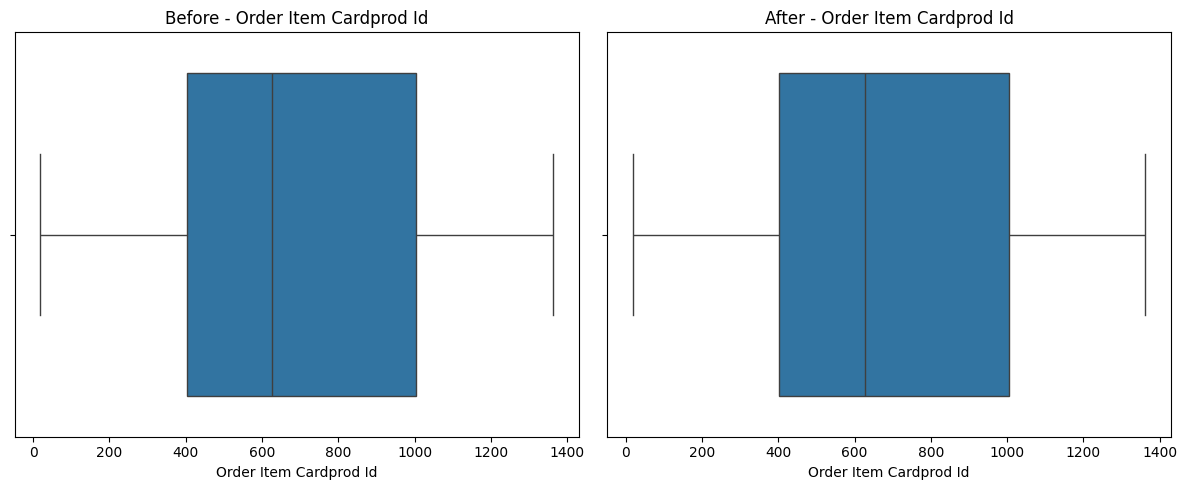

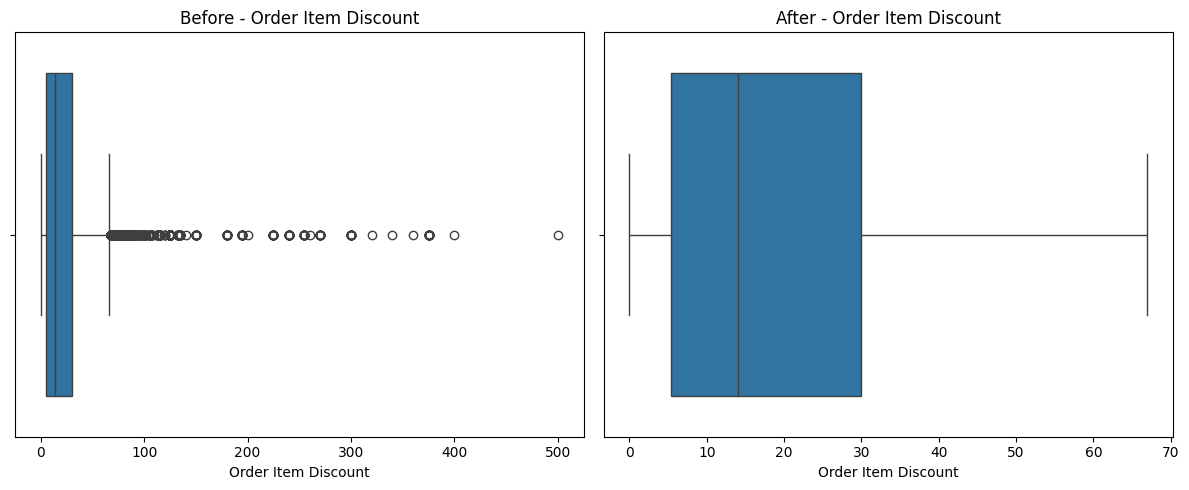

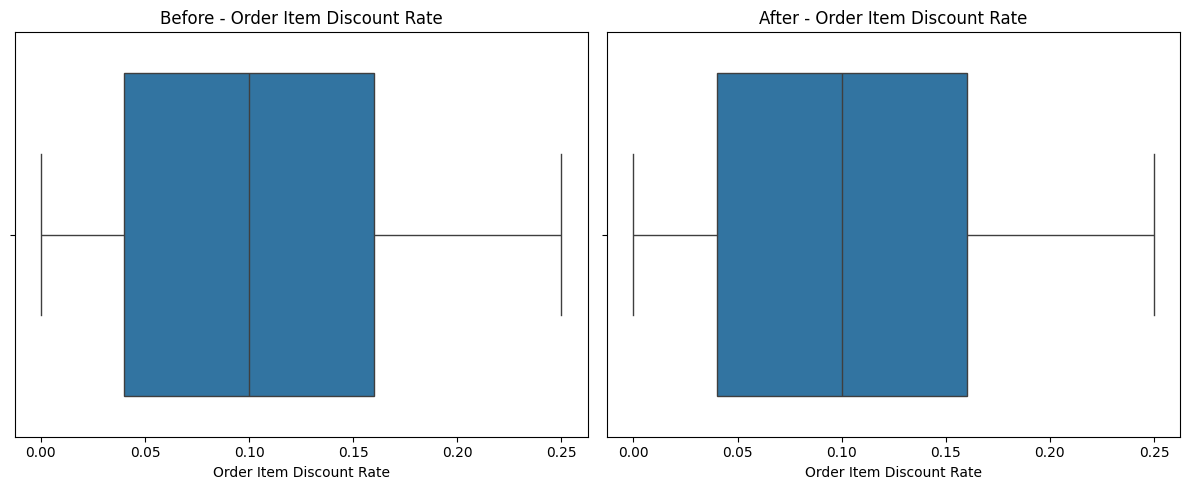

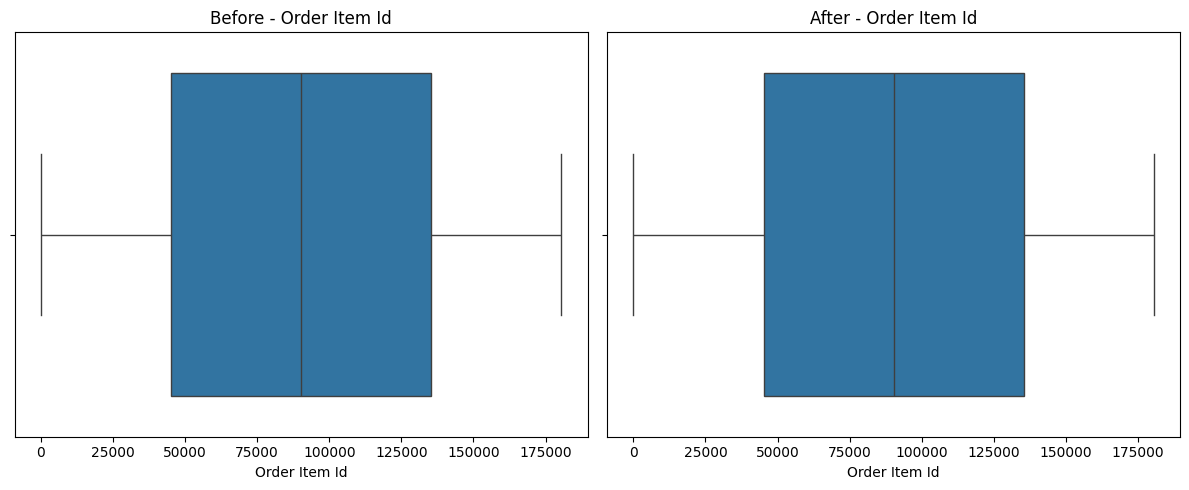

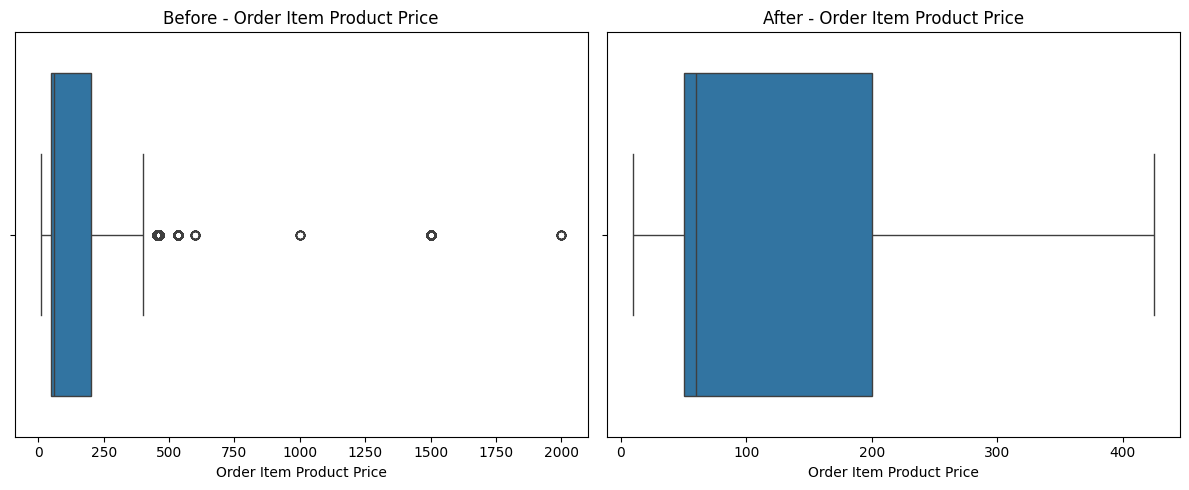

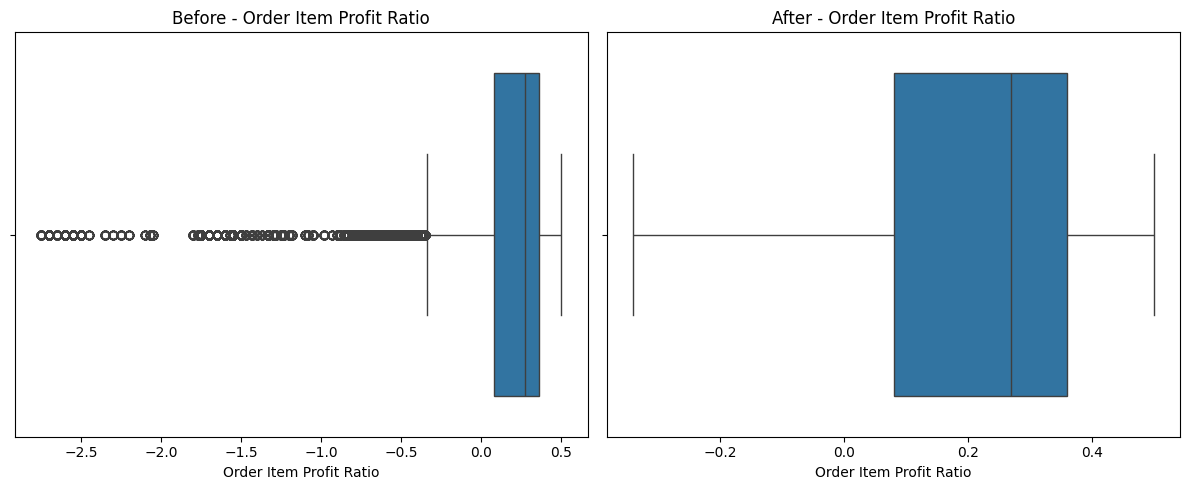

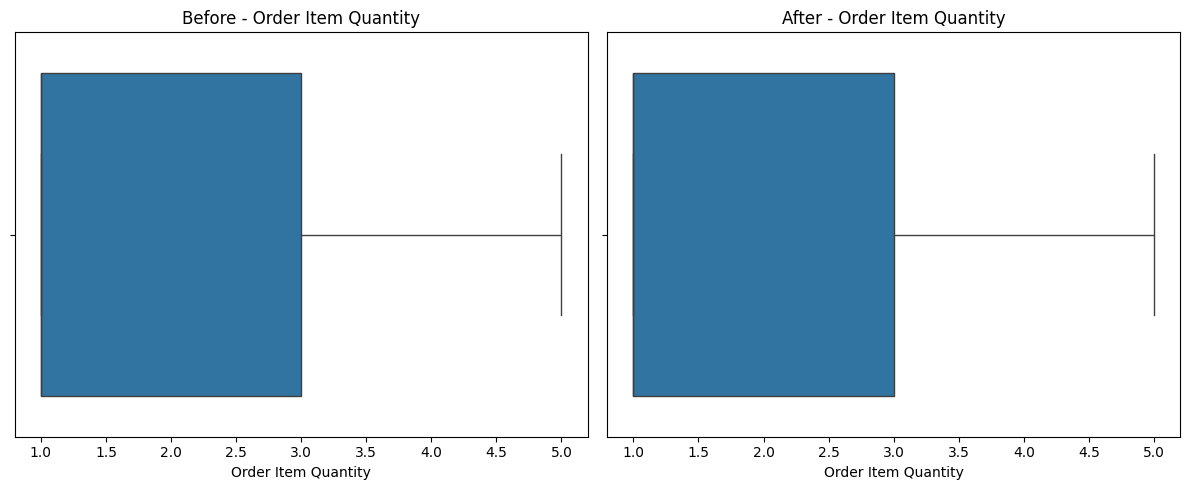

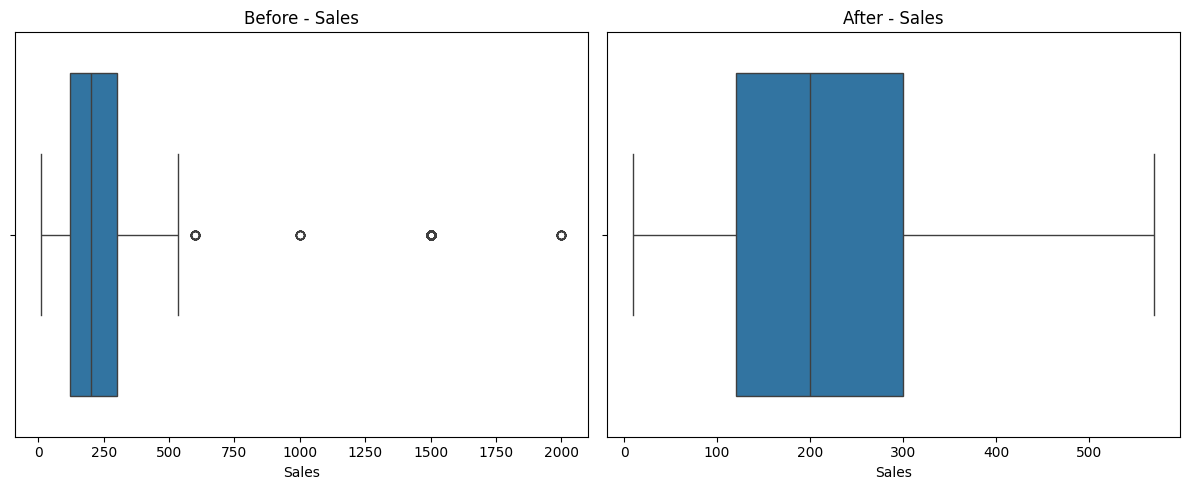

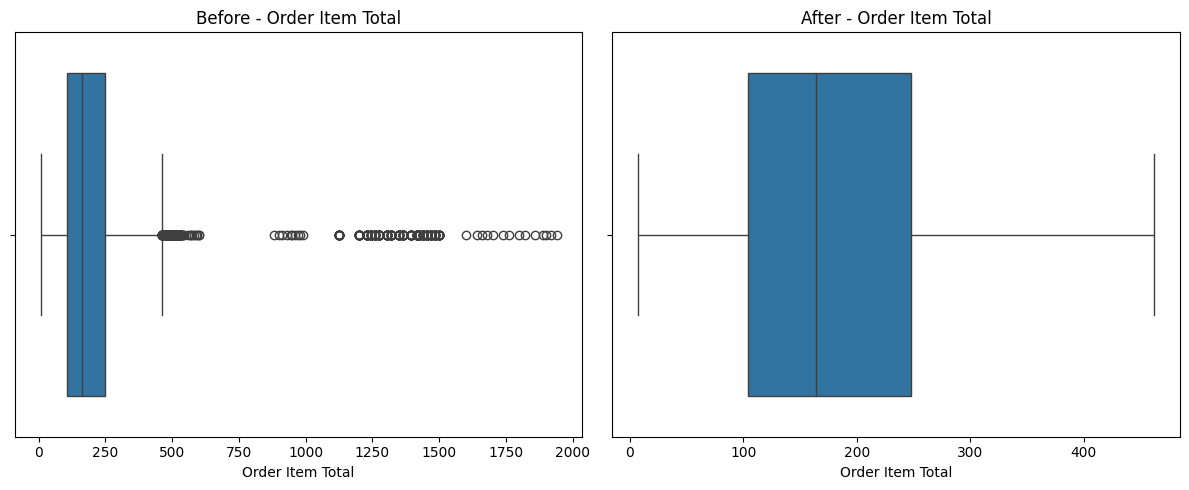

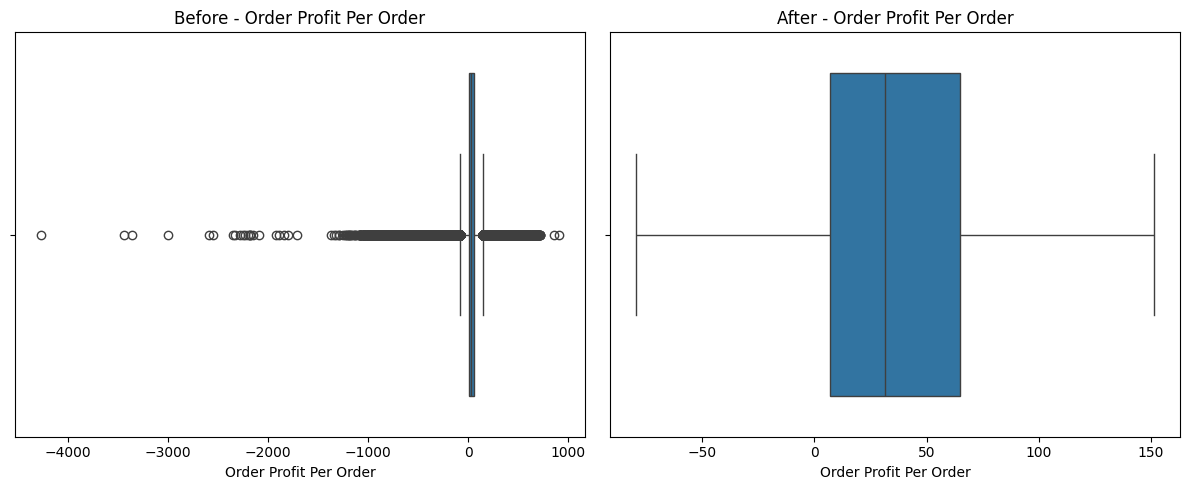

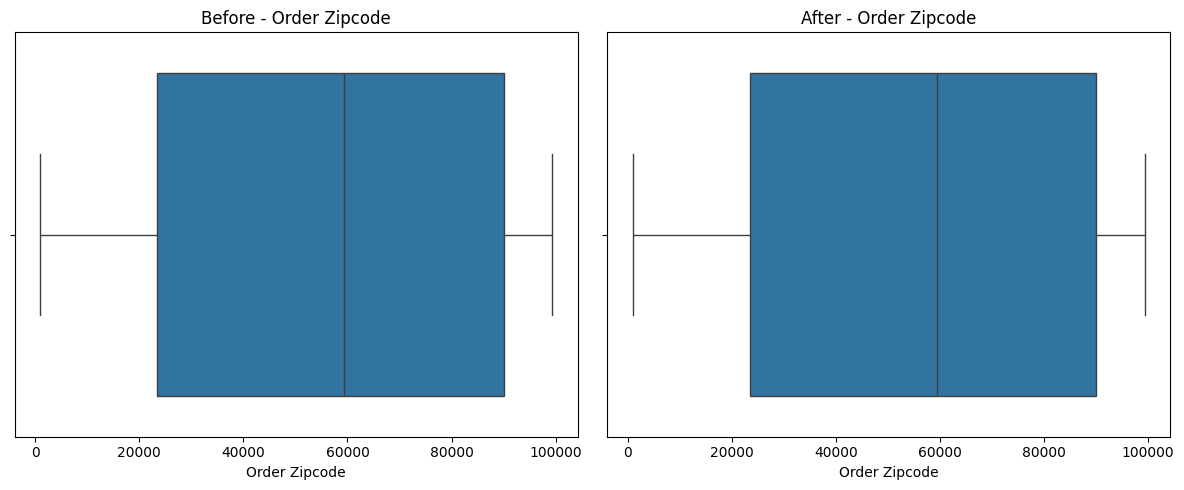

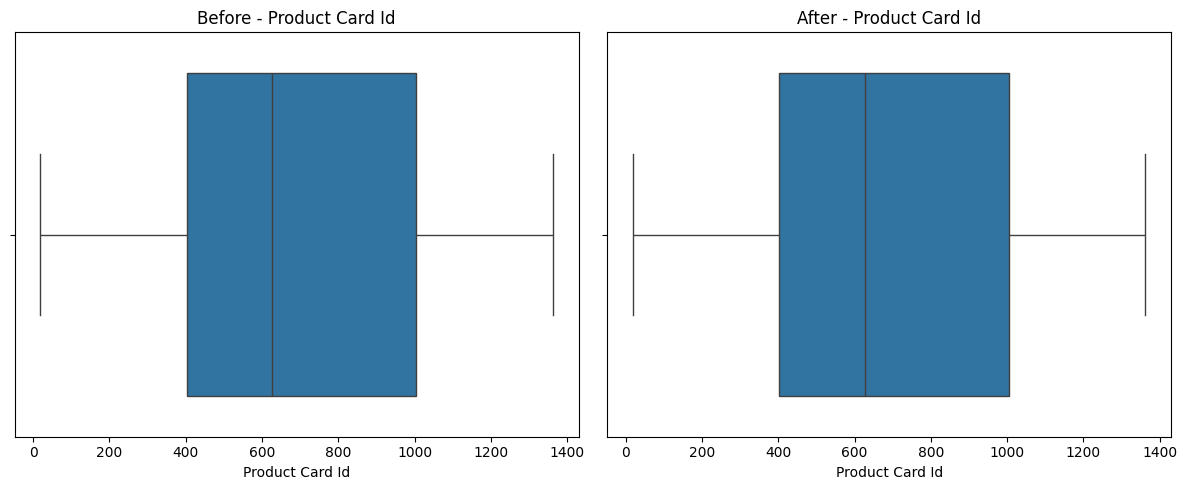

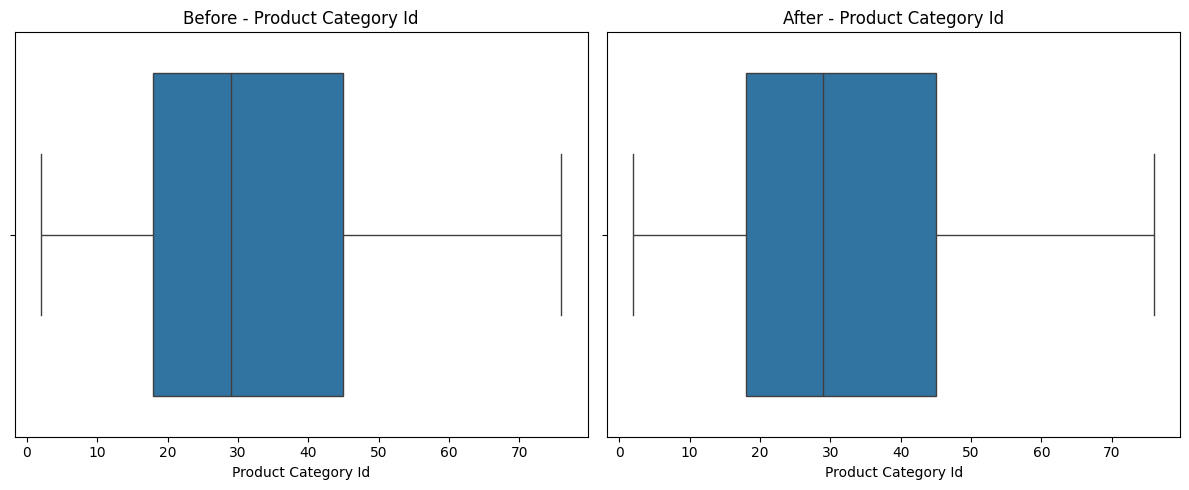

Skipped: Product Description


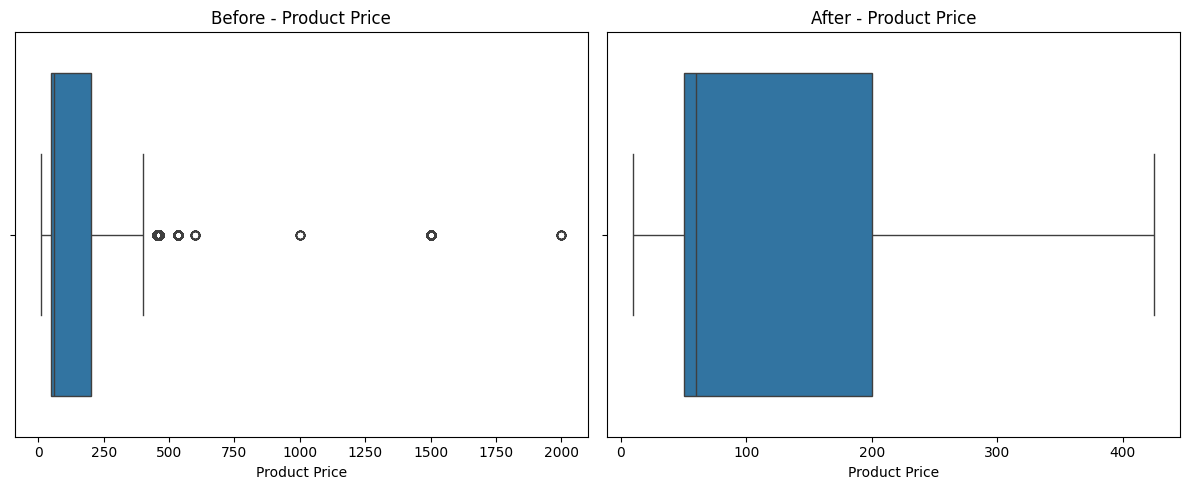

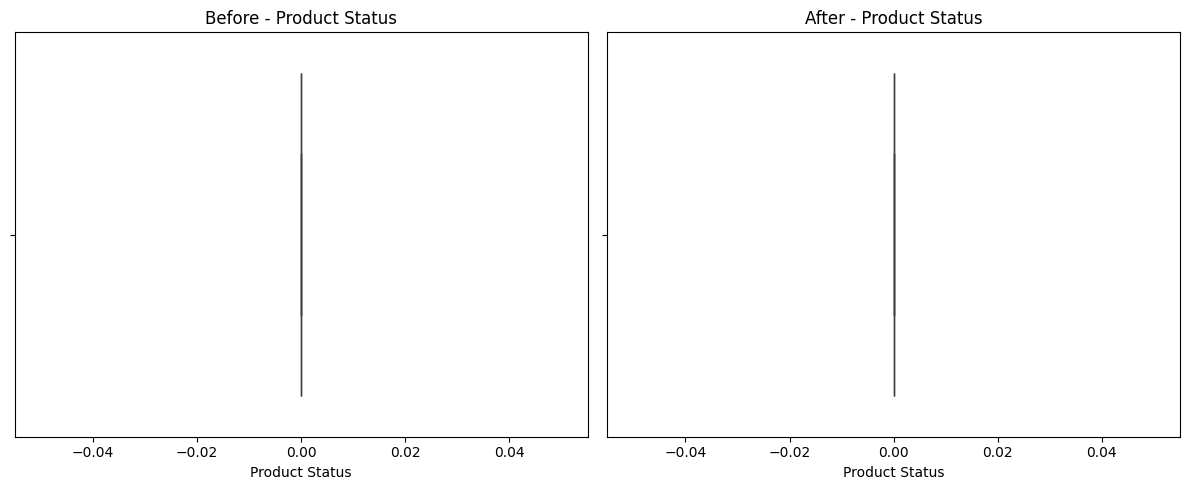

In [29]:
# ============================================
# BEFORE vs AFTER OUTLIER TREATMENT
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Select only numeric columns
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Number of numerical columns:", len(numerical_columns))

for column in numerical_columns:

    # Convert to numeric and remove missing values
    before = pd.to_numeric(df[column], errors="coerce").dropna()
    after = pd.to_numeric(df_clean[column], errors="coerce").dropna()

    # Skip columns with no usable data
    if len(before) == 0 or len(after) == 0:
        print(f"Skipped: {column}")
        continue

    plt.figure(figsize=(12, 5))

    # -------------------------
    # BEFORE
    # -------------------------
    plt.subplot(1, 2, 1)

    sns.boxplot(x=before)

    plt.title(f"Before - {column}")
    plt.xlabel(column)

    # -------------------------
    # AFTER
    # -------------------------
    plt.subplot(1, 2, 2)

    sns.boxplot(x=after)

    plt.title(f"After - {column}")
    plt.xlabel(column)

    plt.tight_layout()
    plt.show()